
# Notebook 3

**Diplomado, Módulo II: Técnicas Estadísticas**


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
from scipy.optimize import minimize_scalar

np.random.seed(2026)



# 1. Estimadores

Un **estimador** es una regla (una fórmula, calculada a partir de una muestra) que usamos para aproximar un parámetro poblacional desconocido (como la media $\mu$, la proporción $p$, o la tasa $\lambda$). Por ejemplo, la media muestral $\bar X$ es el estimador natural de la media poblacional $\mu$.

Es importante no confundir un **estimador** (la fórmula/función, que es aleatoria porque depende de la muestra) con una **estimación** (el número concreto que se obtiene al aplicar la fórmula a los datos observados).

Vamos a ver dos métodos generales para *construir* estimadores: el **método de momentos** y la **estimación por máxima verosimilitud (EMV)**.



## 1.1 Método de momentos

La idea del método de momentos es muy simple: **igualamos los momentos muestrales con los momentos teóricos** de la distribución (que dependen del parámetro que queremos estimar), y despejamos el parámetro.

Por ejemplo, si $X\sim\text{Exp}(\theta)$, sabemos que $\mathbb{E}[X]=1/\theta$. Igualando este momento teórico con el primer momento muestral $\bar X$, obtenemos el estimador:

$$\frac{1}{\theta} = \bar{X} \quad \Longrightarrow \quad \hat{\theta}_{MM} = \frac{1}{\bar{X}}.$$

**Ejemplo.** Se prueban 5 focos de cierta marca y se registra su vida útil (en años): $2, 3, 1, 3, 5$. Suponiendo que la vida útil sigue una distribución exponencial de parámetro $\theta$, estimemos $\theta$ por el método de momentos.


In [2]:
datos_focos = np.array([2, 3, 1, 3, 5])
n_focos = len(datos_focos)

media_muestral = np.mean(datos_focos)
theta_mm = 1 / media_muestral

print("Media muestral (vida útil promedio observada):", media_muestral, "años")
print("Estimador por método de momentos: theta_hat_MM =", round(theta_mm, 4))
print("Entonces la tasa de falla estimada es de", round(theta_mm, 4),
      "focos por año, o dicho de otra forma, una vida media estimada de", media_muestral, "años.")


Media muestral (vida útil promedio observada): 2.8 años
Estimador por método de momentos: theta_hat_MM = 0.3571
Entonces la tasa de falla estimada es de 0.3571 focos por año, o dicho de otra forma, una vida media estimada de 2.8 años.



## 1.2 Estimación por máxima verosimilitud (EMV)

La idea de la **máxima verosimilitud** es distinta: buscamos el valor del parámetro que hace que **los datos que observamos sean los más "creíbles" posibles**. Formalmente, si $X_1,\dots,X_n$ son independientes con densidad (o función de masa) $f(x;\theta)$, la función de verosimilitud es

$$L(\theta) = \prod_{i=1}^{n} f(x_i;\theta),$$

y el estimador de máxima verosimilitud $\hat\theta_{EMV}$ es el valor de $\theta$ que **maximiza** $L(\theta)$ (en la práctica, se maximiza $\log L(\theta)$, que es equivalente y más fácil de derivar).

**Ejemplo 1 (continuando con los focos).** Para $X\sim\text{Exp}(\theta)$, la log-verosimilitud es
$$\log L(\theta) = n\log\theta - \theta\sum_{i=1}^n x_i.$$
En lugar de derivar a mano, vamos a encontrar el valor que la maximiza usando optimización numérica en Python, y compararlo con el estimador de momentos que ya obtuvimos.


Estimador de máxima verosimilitud: theta_hat_MLE = 0.3571
Estimador por método de momentos : theta_hat_MM  = 0.3571
Para la distribución exponencial, ¡ambos métodos coinciden!


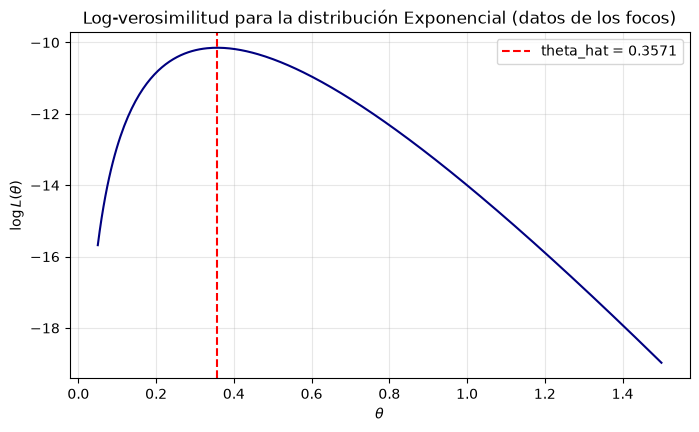

In [3]:
def log_verosimilitud_exp(theta, datos):
    n = len(datos)
    return n * np.log(theta) - theta * np.sum(datos)

# Buscamos theta que MAXIMIZA la log-verosimilitud
# (equivalente a MINIMIZAR el negativo de la log-verosimilitud)
resultado = minimize_scalar(
    lambda th: -log_verosimilitud_exp(th, datos_focos),
    bounds=(1e-6, 5), method='bounded'
)
theta_mle = resultado.x

print("Estimador de máxima verosimilitud: theta_hat_MLE =", round(theta_mle, 4))
print("Estimador por método de momentos : theta_hat_MM  =", round(theta_mm, 4))
print("Para la distribución exponencial, ¡ambos métodos coinciden!")

# Graficamos la log-verosimilitud y marcamos el maximo
theta_vals = np.linspace(0.05, 1.5, 300)
logvero_vals = [log_verosimilitud_exp(th, datos_focos) for th in theta_vals]

plt.figure(figsize=(8, 4.5))
plt.plot(theta_vals, logvero_vals, color='navy')
plt.axvline(theta_mle, color='red', linestyle='--', label=f'theta_hat = {theta_mle:.4f}')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$\log L(\theta)$')
plt.title('Log-verosimilitud para la distribución Exponencial (datos de los focos)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()



**Ejemplo 2 (moneda).** Lanzamos una moneda 100 veces y obtenemos 55 soles. Queremos estimar la probabilidad $p$ de obtener sol. Aquí $X\sim\text{Bin}(100,p)$, y la log-verosimilitud es
$$\log L(p) = x\log p + (n-x)\log(1-p).$$


Estimador de máxima verosimilitud: p_hat = 0.55
Que coincide con la proporción observada: x/n = 0.55


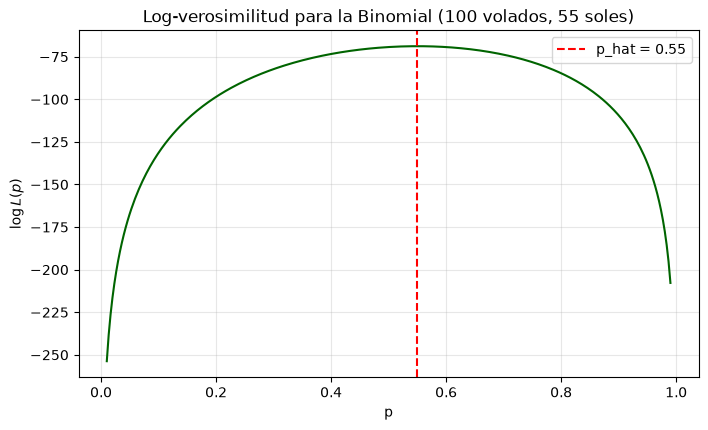

In [4]:
n_moneda, x_moneda = 100, 55

def log_verosimilitud_binomial(p, n, x):
    return x * np.log(p) + (n - x) * np.log(1 - p)

resultado2 = minimize_scalar(
    lambda p: -log_verosimilitud_binomial(p, n_moneda, x_moneda),
    bounds=(1e-6, 1 - 1e-6), method='bounded'
)
p_mle = resultado2.x

print("Estimador de máxima verosimilitud: p_hat =", round(p_mle, 4))
print("Que coincide con la proporción observada: x/n =", x_moneda / n_moneda)

p_vals = np.linspace(0.01, 0.99, 300)
logvero_vals2 = [log_verosimilitud_binomial(p, n_moneda, x_moneda) for p in p_vals]

plt.figure(figsize=(8, 4.5))
plt.plot(p_vals, logvero_vals2, color='darkgreen')
plt.axvline(p_mle, color='red', linestyle='--', label=f'p_hat = {p_mle:.2f}')
plt.xlabel('p')
plt.ylabel(r'$\log L(p)$')
plt.title('Log-verosimilitud para la Binomial (100 volados, 55 soles)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()



En los dos ejemplos, el valor de $\theta$ (o $p$) que maximiza la verosimilitud termina siendo justo lo que uno esperaría de forma intuitiva: la proporción de soles que salió, o el inverso de la vida media que se observó en los focos. No siempre va a ser tan directo con otras distribuciones, pero deja bien claro qué está buscando el EMV en el fondo, el parámetro que hace más creíbles los datos que de verdad observamos.



# 2. Propiedades de los estimadores

No todos los estimadores son igual de buenos. Para comparar y evaluar estimadores, se usan tres propiedades básicas: **insesgadez**, **consistencia** y **eficiencia**. Vamos a explicar cada una y a comprobarlas con simulaciones (apoyándonos en la Ley de los Grandes Números y el Teorema Central del Límite del Notebook 2).



## 2.1 Insesgadez

Un estimador $\hat\theta$ es **insesgado** para $\theta$ si, en promedio (sobre todas las posibles muestras), acierta el valor verdadero:

$$\mathbb{E}[\hat\theta] = \theta.$$

En palabras simples: si repitiéramos el experimento de muestreo muchísimas veces, el promedio de nuestras estimaciones coincidiría con el valor real (no hay una tendencia sistemática a sobreestimar o subestimar).

**Ejemplo clásico:** la varianza muestral. Si dividimos entre $n$ (en lugar de $n-1$), el estimador de la varianza queda **sesgado** (subestima la varianza real, en promedio). Vamos a comprobarlo con una simulación: generamos muchas muestras de una $N(\mu=50,\sigma=10)$, y comparamos el promedio de las varianzas calculadas con `ddof=0` (dividiendo entre $n$) contra las calculadas con `ddof=1` (dividiendo entre $n-1$).


In [5]:
np.random.seed(3)

mu_real, sigma_real = 50, 10
var_real = sigma_real ** 2
n_muestra_sesgo = 10
n_repeticiones_sesgo = 20000

varianzas_sesgadas = []
varianzas_insesgadas = []

for _ in range(n_repeticiones_sesgo):
    muestra = np.random.normal(mu_real, sigma_real, n_muestra_sesgo)
    varianzas_sesgadas.append(np.var(muestra, ddof=0))    # divide entre n (sesgado)
    varianzas_insesgadas.append(np.var(muestra, ddof=1))  # divide entre n-1 (insesgado)

print("Varianza poblacional real                         :", var_real)
print("Promedio de la varianza con ddof=0 (entre n)       :", round(np.mean(varianzas_sesgadas), 2),
      " -> subestima sistematicamente")
print("Promedio de la varianza con ddof=1 (entre n-1)     :", round(np.mean(varianzas_insesgadas), 2),
      " -> coincide con el valor real (insesgado)")


Varianza poblacional real                         : 100
Promedio de la varianza con ddof=0 (entre n)       : 89.29  -> subestima sistematicamente
Promedio de la varianza con ddof=1 (entre n-1)     : 99.21  -> coincide con el valor real (insesgado)



Se ve clarito: el estimador que divide entre $n-1$ (el que usa por defecto `np.var(..., ddof=1)`) sale insesgado, su promedio tras miles de repeticiones coincide con la varianza real (100). El que divide entre $n$ queda sesgado hacia abajo, en promedio subestima la varianza real. Por eso en la práctica casi siempre se usa el divisor $n-1$.



## 2.2 Consistencia

Un estimador $\hat\theta_n$ (que depende del tamaño de muestra $n$) es **consistente** si, conforme $n\to\infty$, se acerca cada vez más al valor verdadero $\theta$ (formalmente, converge en probabilidad a $\theta$). En la práctica, esto significa que su **variabilidad disminuye** a medida que tenemos más datos, tal como vimos con la Ley de los Grandes Números en el Notebook 2.

**Ejemplo.** Comparamos la dispersión de la media muestral $\bar X_n$ (como estimador de $\mu=50$) para distintos tamaños de muestra.


n=   5  ->  promedio de las medias muestrales = 50.031   desviación estándar de las medias = 4.526
n=  20  ->  promedio de las medias muestrales = 49.955   desviación estándar de las medias = 2.275
n= 100  ->  promedio de las medias muestrales = 49.958   desviación estándar de las medias = 1.001
n= 500  ->  promedio de las medias muestrales = 49.991   desviación estándar de las medias = 0.439


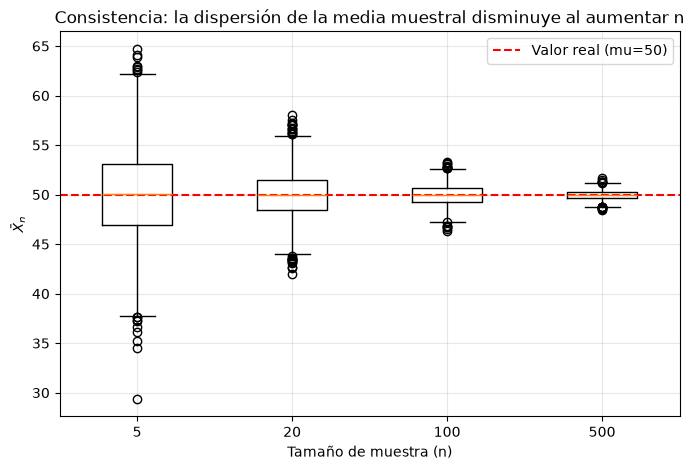

In [6]:
np.random.seed(4)

tamanos_n = [5, 20, 100, 500]
n_repeticiones_cons = 3000

medias_por_n = []
for n in tamanos_n:
    medias = [np.mean(np.random.normal(mu_real, sigma_real, n)) for _ in range(n_repeticiones_cons)]
    medias_por_n.append(medias)
    print(f"n={n:4d}  ->  promedio de las medias muestrales = {np.mean(medias):.3f}   "
          f"desviación estándar de las medias = {np.std(medias):.3f}")

plt.figure(figsize=(8, 5))
plt.boxplot(medias_por_n, tick_labels=[str(n) for n in tamanos_n])
plt.axhline(mu_real, color='red', linestyle='--', label='Valor real (mu=50)')
plt.xlabel('Tamaño de muestra (n)')
plt.ylabel(r'$\bar{X}_n$')
plt.title('Consistencia: la dispersión de la media muestral disminuye al aumentar n')
plt.legend()
plt.grid(alpha=0.3)
plt.show()



En los cuatro casos el promedio de las medias muestrales sale cerca de $\mu=50$, eso ya es la insesgadez de la que hablamos antes. Pero lo que importa ver aquí es que la caja del boxplot se va haciendo más angosta conforme $n$ crece. Con $n=500$ casi todas las medias caen pegaditas a 50. Y eso, ni más ni menos, es lo que significa que un estimador sea consistente.



## 2.3 Eficiencia

Cuando existen **varios estimadores insesgados** para el mismo parámetro, decimos que uno es **más eficiente** que otro si tiene **menor varianza**. Es decir, entre dos estimadores que "aciertan en promedio", preferimos el que varía menos de muestra a muestra (el más preciso).

**Ejemplo.** Para estimar la media $\mu$ de una distribución normal (simétrica), tanto la **media muestral** como la **mediana muestral** son insesgadas. ¿Cuál es más eficiente?


Media de las medias muestrales   : 50.02  (ambas insesgadas, cerca de mu=50)
Media de las medianas muestrales : 50.007

Varianza de la media muestral    : 3.2429
Varianza de la mediana muestral  : 5.0624

Eficiencia relativa (Var(mediana)/Var(media)): 1.561  (la teoría, para la normal, predice un valor cercano a pi/2 ≈ 1.571)


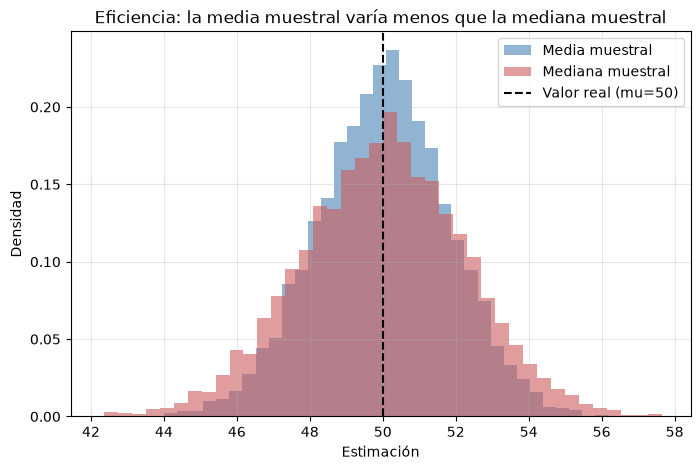

In [7]:
np.random.seed(5)

n_efic = 31
n_repeticiones_efic = 5000

medias_muestrales = []
medianas_muestrales = []

for _ in range(n_repeticiones_efic):
    muestra = np.random.normal(mu_real, sigma_real, n_efic)
    medias_muestrales.append(np.mean(muestra))
    medianas_muestrales.append(np.median(muestra))

print("Media de las medias muestrales   :", round(np.mean(medias_muestrales), 3), " (ambas insesgadas, cerca de mu=50)")
print("Media de las medianas muestrales :", round(np.mean(medianas_muestrales), 3))
print()
print("Varianza de la media muestral    :", round(np.var(medias_muestrales), 4))
print("Varianza de la mediana muestral  :", round(np.var(medianas_muestrales), 4))
print()
print("Eficiencia relativa (Var(mediana)/Var(media)):",
      round(np.var(medianas_muestrales) / np.var(medias_muestrales), 3),
      " (la teoría, para la normal, predice un valor cercano a pi/2 ≈ 1.571)")

plt.figure(figsize=(8, 5))
plt.hist(medias_muestrales, bins=40, alpha=0.6, density=True, label='Media muestral', color='steelblue')
plt.hist(medianas_muestrales, bins=40, alpha=0.6, density=True, label='Mediana muestral', color='indianred')
plt.axvline(mu_real, color='black', linestyle='--', label='Valor real (mu=50)')
plt.xlabel('Estimación')
plt.ylabel('Densidad')
plt.title('Eficiencia: la media muestral varía menos que la mediana muestral')
plt.legend()
plt.grid(alpha=0.3)
plt.show()



Los dos estimadores quedan centrados en el valor real ($\mu=50$), o sea que los dos son insesgados. Pero el histograma de la media muestral se ve claramente más angosto que el de la mediana muestral, la media varía menos de una muestra a otra. Entonces para datos normales la media muestral le gana en eficiencia a la mediana como estimador de $\mu$ (y de hecho la teoría dice que la mediana necesitaría como $\pi/2\approx 1.57$ veces más observaciones que la media para llegar a la misma precisión, número que casi calza exacto con lo que salió en la simulación).



### Conclusión de estimadores y sus propiedades

De esta parte me queda claro que un buen estimador no es nada más una fórmula que "suene razonable". Lo ideal es que sea insesgado (sin un error sistemático hacia arriba o hacia abajo), consistente (que mejore entre más datos le demos) y eficiente (que varíe lo menos posible comparado con otros estimadores insesgados). El método de momentos y la máxima verosimilitud son las dos formas que vimos para construir un estimador, y estas tres propiedades son la forma de juzgar qué tan bueno terminó siendo.



# 3. Intervalos de confianza

Una estimación puntual (un solo número, como $\bar X$) no nos dice nada sobre qué tan confiable es. Un **intervalo de confianza** es en cambio un rango de valores, construido a partir de la muestra, que con cierto nivel de confianza (por ejemplo 95%) contiene al verdadero parámetro poblacional.

Gracias al **Teorema Central del Límite** (Notebook 2), sabemos que la media muestral $\bar X$ se distribuye aproximadamente normal para muestras grandes, sin importar la distribución original de los datos. Esto es justamente lo que nos permite construir estos intervalos.



## 3.1 Intervalo de confianza para la media, con $\sigma$ conocida

Si conocemos la desviación estándar poblacional $\sigma$, el intervalo del $(1-\alpha)\times100\%$ de confianza para $\mu$ es:

$$\bar{X} \pm z_{\alpha/2}\frac{\sigma}{\sqrt{n}},$$

donde $z_{\alpha/2}$ es el valor crítico de la normal estándar, y $\sigma/\sqrt n$ es el error estándar.

**Ejemplo.** Para estimar el consumo promedio por cliente en un restaurante, se toma una muestra de $n=49$ clientes, con media muestral $\bar X=\$22.60$. Se sabe (por estudios previos) que la desviación estándar poblacional es $\sigma=\$2.5$. Construyamos el intervalo de confianza del 95%.


In [8]:
n1, sigma1, media1, confianza1 = 49, 2.5, 22.60, 0.95

error_estandar1 = sigma1 / np.sqrt(n1)
intervalo1 = st.norm.interval(confianza1, loc=media1, scale=error_estandar1)

print("Error estándar:", round(error_estandar1, 4))
print(f"Intervalo de confianza del {confianza1*100:.0f}%: (${intervalo1[0]:.2f}, ${intervalo1[1]:.2f})")
print(f"Con un {confianza1*100:.0f}% de confianza, el consumo promedio poblacional "
      f"por cliente está entre ${intervalo1[0]:.2f} y ${intervalo1[1]:.2f}.")


Error estándar: 0.3571
Intervalo de confianza del 95%: ($21.90, $23.30)
Con un 95% de confianza, el consumo promedio poblacional por cliente está entre $21.90 y $23.30.



## 3.2 Intervalo de confianza para la media, con $\sigma$ desconocida

Cuando no conocemos $\sigma$, la estimamos con la desviación estándar muestral $s$, y en su lugar usamos la distribución $t$ de Student con $n-1$ grados de libertad (que tiene colas más pesadas, para compensar la incertidumbre extra de estimar $\sigma$):

$$\bar{X} \pm t_{\alpha/2,\,n-1}\frac{s}{\sqrt{n}}.$$

**Ejemplo.** Con una muestra pequeña de 10 observaciones: $45,55,67,68,45,79,98,87,84,82$, calculemos el intervalo de confianza del 99% para la media.


In [9]:
datos_ic = [45, 55, 67, 68, 45, 79, 98, 87, 84, 82]
n2 = len(datos_ic)
gl = n2 - 1
confianza2 = 0.99

media2 = np.mean(datos_ic)
error_estandar2 = st.sem(datos_ic)  # = s / sqrt(n)

intervalo2 = st.t.interval(confianza2, gl, loc=media2, scale=error_estandar2)

print("Media muestral:", round(media2, 2))
print("Grados de libertad:", gl)
print(f"Intervalo de confianza del {confianza2*100:.0f}%: ({intervalo2[0]:.2f}, {intervalo2[1]:.2f})")
print(f"Con un {confianza2*100:.0f}% de confianza, la media poblacional está "
      f"entre {intervalo2[0]:.2f} y {intervalo2[1]:.2f}. Como la muestra es chica (n=10) y no "
      f"conocemos sigma, usamos la t de Student en lugar de la normal, y por eso el intervalo sale "
      f"un poco más ancho, para compensar que estamos estimando también la desviación estándar.")


Media muestral: 71.0
Grados de libertad: 9
Intervalo de confianza del 99%: (52.32, 89.68)
Con un 99% de confianza, la media poblacional está entre 52.32 y 89.68. Como la muestra es chica (n=10) y no conocemos sigma, usamos la t de Student en lugar de la normal, y por eso el intervalo sale un poco más ancho, para compensar que estamos estimando también la desviación estándar.



## 3.3 Intervalo de confianza para una proporción

Cuando el parámetro de interés es una proporción $p$ (por ejemplo, la fracción de personas que prefieren algo), el estimador puntual es $\hat p = x/n$. Como $\hat p$ también es aproximadamente normal para $n$ grande (gracias, de nuevo, al TCL), el intervalo de confianza es:

$$\hat{p} \pm z_{\alpha/2}\sqrt{\frac{\hat p(1-\hat p)}{n}}.$$

**Ejemplo.** En una encuesta, 100 de 225 estudiantes que toman Cálculo dijeron que es su materia favorita. Construyamos el intervalo de confianza del 95% para la verdadera proporción de estudiantes que prefieren Cálculo.


In [10]:
n3, x3, confianza3 = 225, 100, 0.95

p_hat = x3 / n3
error_estandar3 = np.sqrt(p_hat * (1 - p_hat) / n3)
z_critico = st.norm.ppf(1 - (1 - confianza3) / 2)
margen_error = z_critico * error_estandar3

limite_inf = p_hat - margen_error
limite_sup = p_hat + margen_error

print("Proporción muestral p_hat:", round(p_hat, 4))
print("Margen de error:", round(margen_error, 4))
print(f"Intervalo de confianza del {confianza3*100:.0f}%: ({limite_inf:.4f}, {limite_sup:.4f})")
print(f"Con un {confianza3*100:.0f}% de confianza, entre el {limite_inf*100:.1f}% y "
      f"el {limite_sup*100:.1f}% de todos los estudiantes de Cálculo lo consideran su materia favorita.")


Proporción muestral p_hat: 0.4444
Margen de error: 0.0649
Intervalo de confianza del 95%: (0.3795, 0.5094)
Con un 95% de confianza, entre el 38.0% y el 50.9% de todos los estudiantes de Cálculo lo consideran su materia favorita.



## 3.4 Ejercicio adicional (media, muestra grande)

Los ingresos semanales promedio de las personas que trabajan en servicios fueron de \$369, según una muestra de $n=250$ personas, con desviación estándar muestral $s=\$50$. Aunque no conocemos $\sigma$ poblacional, como $n=250$ es grande, usamos la distribución normal (en vez de la $t$) para el intervalo del 95%.


In [11]:
n4, media4, s4, confianza4 = 250, 369, 50, 0.95

error_estandar4 = s4 / np.sqrt(n4)
intervalo4 = st.norm.interval(confianza4, loc=media4, scale=error_estandar4)

print("Error estándar:", round(error_estandar4, 4))
print(f"Intervalo de confianza del {confianza4*100:.0f}%: (${intervalo4[0]:.2f}, ${intervalo4[1]:.2f})")
print(f"Con un {confianza4*100:.0f}% de confianza, el ingreso semanal promedio "
      f"poblacional de quienes trabajan en servicios está entre ${intervalo4[0]:.2f} y ${intervalo4[1]:.2f}.")


Error estándar: 3.1623
Intervalo de confianza del 95%: ($362.80, $375.20)
Con un 95% de confianza, el ingreso semanal promedio poblacional de quienes trabajan en servicios está entre $362.80 y $375.20.



## 3.5 Bonus: intervalo de confianza para la varianza

Aunque no es obligatorio en el temario, vale la pena mencionar que también se puede construir un intervalo de confianza para la **varianza** poblacional $\sigma^2$, usando la distribución ji-cuadrada ($\chi^2$) con $n-1$ grados de libertad:

$$\left(\frac{(n-1)s^2}{\chi^2_{1-\alpha/2}},\; \frac{(n-1)s^2}{\chi^2_{\alpha/2}}\right).$$

**Ejemplo.** La resistencia a la ruptura de cierto material cerámico se midió en una muestra de $n=100$ artículos, con media $1750$ y desviación estándar muestral $315.8$. Calculemos el intervalo de confianza del 90% para la varianza poblacional.


In [12]:
n5, s5, confianza5 = 100, 315.8, 0.90
gl5 = n5 - 1
alpha5 = 1 - confianza5
s2_5 = s5 ** 2

chi_inf = st.chi2.ppf(alpha5 / 2, gl5)
chi_sup = st.chi2.ppf(1 - alpha5 / 2, gl5)

intervalo_var = ((gl5 * s2_5) / chi_sup, (gl5 * s2_5) / chi_inf)

print(f"Intervalo de confianza del {confianza5*100:.0f}% para la varianza: "
      f"({intervalo_var[0]:.2f}, {intervalo_var[1]:.2f})")
print("Con un 90% de confianza, la varianza poblacional de la resistencia a la ruptura "
      "cae entre estos dos valores. Sacando raíz cuadrada, la desviación estándar poblacional queda "
      f"entre {np.sqrt(intervalo_var[0]):.2f} y {np.sqrt(intervalo_var[1]):.2f}.")


Intervalo de confianza del 90% para la varianza: (80123.49, 128146.72)
Con un 90% de confianza, la varianza poblacional de la resistencia a la ruptura cae entre estos dos valores. Sacando raíz cuadrada, la desviación estándar poblacional queda entre 283.06 y 357.98.



### Conclusión

En este notebook aprendí cómo estimar parámetros poblacionales que no conocemos, ya sea con el método de momentos o con máxima verosimilitud, y sobre todo cómo saber si esos estimadores son buenos o no, viendo si son insesgados, si son consistentes y qué tan eficientes son. Y ya con eso, di el siguiente paso: cuantificar qué tan segura puedo estar de una estimación puntual usando intervalos de confianza, tanto para una media como para una proporción.

Viéndolo en retrospectiva, los tres notebooks se conectan bastante entre sí. El primero me dio las bases de la probabilidad, el segundo me dio las distribuciones y, sobre todo, la Ley de los Grandes Números y el Teorema Central del Límite, y este tercero termina usando esas dos ideas como columna vertebral: la LGN es la razón por la que un promedio muestral se acerca al parámetro real (por eso funciona como estimador), y el TCL me dice cómo se distribuyen esos promedios, que es justo lo que necesito para poder armar intervalos de confianza válidos aunque no sepa cuál es la distribución original de los datos.



## Bibliografía

- Rincón, L. (2023). *Curso intermedio de probabilidad*. Facultad de Ciencias, UNAM.
- Ross, S. M. (2019). *A First Course in Probability* (10th ed.). Pearson.
- Mood, A. M., Graybill, F. A., & Boes, D. C. (1974). *Introduction to the Theory of Statistics* (3rd ed.). McGraw-Hill.
- Mendenhall, W., Beaver, R. J., & Beaver, B. M. (2013). *Introduction to Probability and Statistics* (14th ed.). Cengage Learning.
- Documentación oficial de SciPy: [scipy.stats](https://docs.scipy.org/doc/scipy/reference/stats.html)
- Documentación oficial de NumPy: [numpy.random](https://numpy.org/doc/stable/reference/random/index.html)

*Nota: esta bibliografía corresponde al material de referencia usado a lo largo de los tres notebooks de la entrega final (Espacio de probabilidad, Variables aleatorias y Estadística inferencial).*
